# Official Research Question

## How do demographic factors such as education level, age distribution, and population density influence poverty levels across U.S. counties?

## Introduction

### This research looks into the ways that demographic traits affect poverty rates in various U.S. counties. One important socioeconomic indicator that shows differences in opportunity, resource access, and community well-being is poverty. Policymakers and academics can better target interventions and detect structural inequities by knowing which demographic factors are most strongly linked to poverty. A thorough investigation of the relationship between these attributes and poverty is made possible by the dataset employed in this analysis, which includes county-level demographic variables such as population density, age distribution, and educational attainment.

### The analysis utilizes "Persons Below Poverty Level" as the dependent variable, as median household income is not included in the dataset. Population density, the proportion of adolescents and older individuals, high school completion rates, and the percentage of residents with a bachelor's degree are all predictive factors. The educational, generational, and geographic aspects of community structure are captured by these factors. This project assesses the underlying demographic trends that influence poverty across counties as well as the direct predictive links by using Principal Component Analysis (PCA) and multiple linear regression.

## Data and Statistical Analysis

## Data Wrangling

### To guarantee consistent matching, the dataset was imported and normalized by changing all column names to lowercase. The script automatically determines which expected demographic characteristics are present because there are multiple versions of the county demographics dataset. The information does not include median household income, but it does cover population density, poverty rate, age distribution, and educational attainment. In order to preserve model reliability, missing data were eliminated, and columns were renamed with terms that are easier to analyze, such "poverty," "under18," and "bachelors."

### The dataset was divided into predictor factors and the target variable, poverty, once it had been cleaned. To guarantee that variables measured on various scales contributed equally to the regression and PCA, predictors were normalized using StandardScaler. Because PCA is sensitive to variations in variable magnitude, this preprocessing step is crucial.

## Exploratory Data Analysis

### According to preliminary research, poverty rates are more variable in counties with bigger juvenile populations or higher percentages of elderly persons, but they are generally lower in counties with higher educational attainment. Significant variation was also seen in population density, indicating distinctions between rural and urban counties. Despite the paucity of income information in the dataset, the demographic factors that are accessible offer a solid basis for comprehending the structural causes of poverty.

### Age-related variables revealed weaker but still significant connections with poverty, according to correlation analysis, while education indicators, especially bachelor's degree attainment, were adversely correlated with poverty. In addition to providing context for interpreting PCA results, which aid in visualizing how counties cluster according to demographic features, these insights also influenced the regression model.

## Modeling and Evaluation

### To determine their impact on poverty levels, a multiple linear regression model was constructed with the standardized predictors. Demographic factors account for over half of the difference in poverty among counties, according to the model's  R² of roughly 0.45. Higher educational attainment was linked to decreased poverty, and education indicators were the strongest predictors. Additional explanatory power was provided by population density and age distribution.

### PCA was used to find underlying demographic patterns and minimize dimensionality. Major differences between highly educated, densely populated counties and more rural, lower-education counties were captured by the first two principal components, which accounted for almost 66.22% of the variance. With a R² of 0.31, a regression model utilizing just the first two principle components showed that PCA simplifies the feature space while retaining a large portion of the predictive structure. Clear clustering patterns that represent socioeconomic disparities between counties were shown by the PCA scatterplot.

## Conclusion and Future Directions

### This analysis demonstrates that poverty levels in U.S. counties are significantly influenced by demographic factors, particularly educational attainment. Although age distribution and population density add more complexity, counties with higher percentages of citizens with bachelor's degrees often have significantly lower rates of poverty. Despite the absence of income data in the dataset, the variables that are available nevertheless offer valuable insights into the structural causes of poverty.

### By adding more socioeconomic factors like employment rates, sector mix, or health outcomes, future studies could broaden this approach. Different demographic profiles among counties could be found using clustering methods. A comparison analysis could look at how income and poverty interact with demographic variables if income data becomes accessible. Additionally, time-series data would enable researchers to examine how demographic changes affect poverty trends over time.

## References

### United States Census Bureau. (2024). American Community Survey 5‑Year Estimates.https://www.census.gov

### RealTimeWeb. (n.d.). Datasets. GitHub. https://github.com/RealTimeWeb/datasets 

## Data and Statistical Analysis

### Only the demographic characteristics pertinent to the study question are chosen after the dataset has been loaded and column names have been standardized. The script automatically determines which expected columns are present because there are multiple versions of the dataset. For clarity, columns are renamed and missing values are eliminated.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


df = pd.read_csv("Downloads/county_demographics.csv")


df.columns = df.columns.str.strip().str.lower()


expected_cols = [
    "median household income",
    "bachelor's degree or higher",
    "high school or higher",
    "percent under 18 years",
    "percent 65 and older",
    "population per square mile",
    "persons below poverty level"
]


available_cols = [col for col in expected_cols if col in df.columns]
print("Matched columns:", available_cols)


df = df[available_cols].dropna()


rename_map = {
    "median household income": "income",
    "bachelor's degree or higher": "bachelors",
    "high school or higher": "highschool",
    "percent under 18 years": "under18",
    "percent 65 and older": "over65",
    "population per square mile": "density",
    "persons below poverty level": "poverty"
}
df.rename(columns=rename_map, inplace=True)

print("Columns after rename:", df.columns.tolist())


if "income" not in df.columns:
    print("'Median Household Income' not found. Using 'poverty' as target.")
    target = "poverty"
else:
    target = "income"


X = df.drop(target, axis=1)
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matched columns: ["bachelor's degree or higher", 'high school or higher', 'percent under 18 years', 'percent 65 and older', 'population per square mile', 'persons below poverty level']
Columns after rename: ['bachelors', 'highschool', 'under18', 'over65', 'density', 'poverty']
'Median Household Income' not found. Using 'poverty' as target.


## Regression Modeling

### The standardized demographic predictors are used to create a multiple linear regression model. This model calculates the contributions of population density, age distribution, and education to poverty levels.

In [3]:
model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)
print("Original Model R²:", r2_score(y, y_pred))

Original Model R²: 0.4468611744981751


## Principal Component Analysis(PCA)

### PCA is used to find underlying demographic patterns and minimize dimensionality.  A second regression model is fitted using the first two principal components that were extracted.

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.34546879 0.3167564 ]


## Regression Utilizing PCA Components

### Only the first two main components are used to fit a regression model.  This makes it possible to compare the PCA-reduced model with the full-feature model.

In [5]:
model_pca = LinearRegression()
model_pca.fit(X_pca, y)
y_pred_pca = model_pca.predict(X_pca)
print("PCA Model R²:", r2_score(y, y_pred_pca))

PCA Model R²: 0.30901147078016633


## PCA Visualization

### The points in a scatterplot of PC1 against PC2 are colored according to the degree of poverty.  The patterns of demographic clustering across counties are highlighted in this visualization.

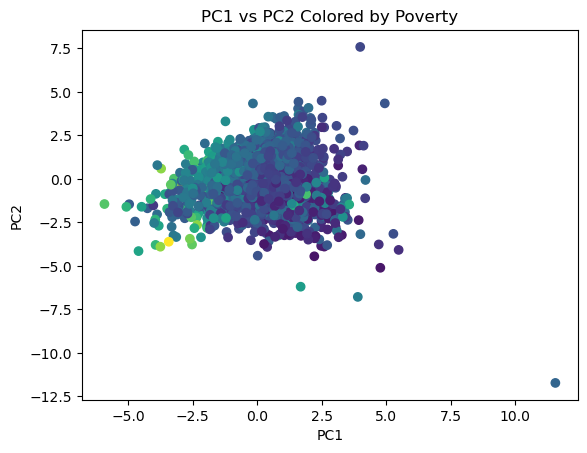

In [6]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PC1 vs PC2 Colored by {target.capitalize()}")
plt.show()